# Survival Analysis

In [2]:
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import logrank_test
import matplotlib.pyplot as plt 
import pandas as pd

Median survival time: inf months
12-month retention: 84.3%
24-month retention: 78.9%


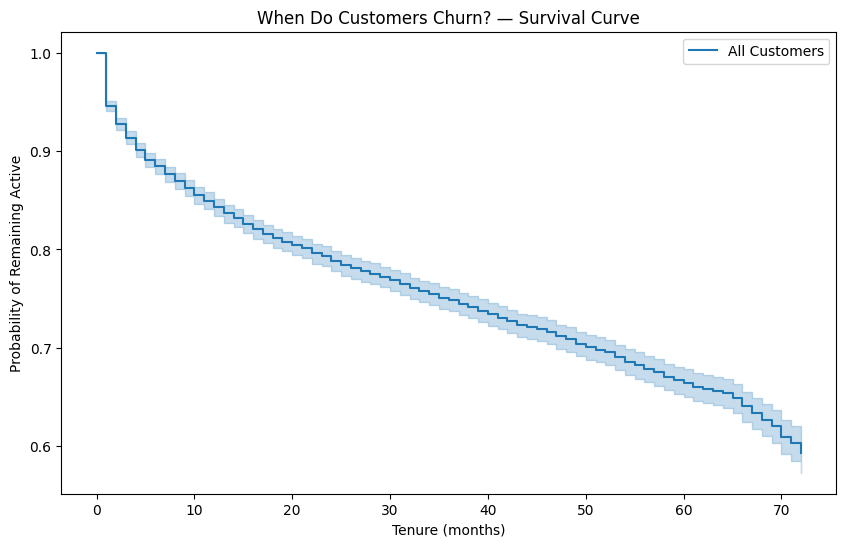

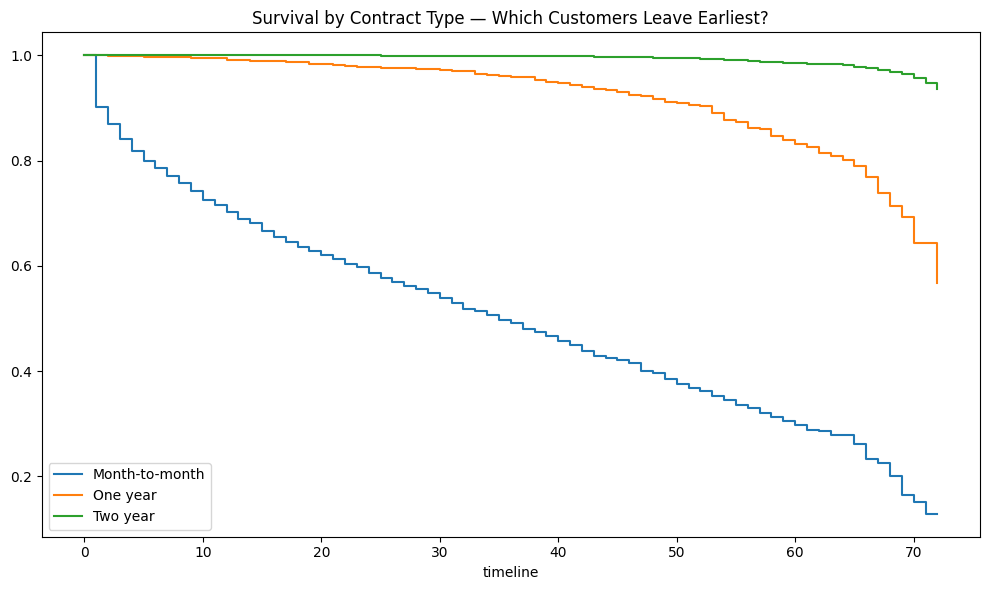

In [3]:
data = pd.read_parquet("../data/processed/features.parquet")

# -- Kalpan-Meier overall survival curve
kmf = KaplanMeierFitter()
kmf.fit(durations=data['tenure'], event_observed = data['Churn_binary'],
        label = "All Customers")
ax = kmf.plot_survival_function(ci_show=True, figsize=(10,6))
ax.set_xlabel('Tenure (months)')
ax.set_ylabel('Probability of Remaining Active')
ax.set_title('When Do Customers Churn? — Survival Curve')

# Annotation at key time points
median_survival = kmf.median_survival_time_
print(f'Median survival time: {median_survival:.0f} months')
print(f'12-month retention: {kmf.predict(12):.1%}')
print(f'24-month retention: {kmf.predict(24):.1%}')

# ── Segment Comparison — Month-to-Month vs Long-term ──────────
fig, ax = plt.subplots(figsize=(10,6))
for contract_type, group in data.groupby('Contract'):
    kmf_seg = KaplanMeierFitter()
    kmf_seg.fit(group['tenure'], group['Churn_binary'], label=contract_type)
    kmf_seg.plot_survival_function(ax=ax, ci_show=False)

ax.set_title('Survival by Contract Type — Which Customers Leave Earliest?')
plt.tight_layout()



In [4]:
# ── Log-Rank Test — Is the Difference Statistically Significant? ─
mtm    = data[data['Contract']=='Month-to-month']
annual = data[data['Contract']!='Month-to-month']

results = logrank_test(
    mtm['tenure'], annual['tenure'],
    event_observed_A=mtm['Churn_binary'],
    event_observed_B=annual['Churn_binary']
)
print(f'Log-rank test p-value: {results.p_value:.6f}')
print(f'Significant difference: {results.p_value < 0.05}')


Log-rank test p-value: 0.000000
Significant difference: True


In [16]:
data.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn',
       'Churn_binary', 'revenue_per_tenure', 'is_long_term', 'service_count',
       'tenure_band', 'TechSupport_encoded'],
      dtype='object')

In [ ]:
# ── Cox Proportional Hazards — Multi-Variable Survival Regression
# Quantifies the effect of each variable on churn timing
data['TechSupport_encoded'] = data['TechSupport'].map({
    'No': 0,
    'Yes': 1,
    'No internet service': 0
})

cox_features = ['tenure','MonthlyCharges','SeniorCitizen',
                'is_long_term','service_count','TechSupport_encoded']

cph = CoxPHFitter()
cph.fit(data[cox_features + ['Churn_binary']], duration_col='tenure',
        event_col='Churn_binary')
print(round(cph.summary,4))
# Hazard ratio > 1 means the variable increases churn risk
# Hazard ratio < 1 means the variable is protective

                       coef  exp(coef)  se(coef)  coef lower 95%  \
covariate                                                          
MonthlyCharges       0.0334     1.0340    0.0018          0.0299   
SeniorCitizen       -0.0499     0.9514    0.0551         -0.1579   
is_long_term        -2.5190     0.0805    0.0848         -2.6853   
service_count       -0.5365     0.5848    0.0267         -0.5889   
TechSupport_encoded  0.0220     1.0223    0.0711         -0.1174   

                     coef upper 95%  exp(coef) lower 95%  exp(coef) upper 95%  \
covariate                                                                       
MonthlyCharges               0.0370               1.0303               1.0377   
SeniorCitizen                0.0582               0.8539               1.0599   
is_long_term                -2.3528               0.0682               0.0951   
service_count               -0.4842               0.5550               0.6162   
TechSupport_encoded          0.1614  

### Statistical Findings

- MonthlyCharges: Every $1 increase in the monthly charges there is instantaneous risk of churn by approximate 3.4%
- LongTerm: Customers of lon-term contracts, experience lower chances of churn in comparison to month-to-month contracts
- Service Count: Each additional service opted, reduces the churn hazard by roughly 41%

### Business Findings

- Customers paying higher monthly fees are more likely to cancel. Thereby suggesting, pricing sensitivity to be a meaningful driver of Churn
- Contract commitmment is the strongest protective factor. Engaging customers to move from month-to-month contract to annual contract would substantially improve retention and churn risk
- Customers using more services are less likely to churn. Increasing product adoption through onboarding campaigns and feature education may improve retention and making customers more involved into the platform

The analysis using Cox Proportional Hazards model identified three key drivers of churn timing. 
- Contract type emerged as the strongest protective factor, with customers on long-term contracts exhibiting a substantially lower hazard of churn than month-to-month customers. 
- Higher monthly charges were associated with increased churn risk, indicating price sensitivity remains an important driver of customer attrition. 
- In addition, customers using a greater number of services experienced significantly lower churn hazards, suggesting that deeper product adoption improves customer retention. D
- emographic characteristics such as senior citizen status and access to technical support were not statistically significant after controlling for other variables.